<a href="https://colab.research.google.com/github/si-janenunes/CURSO-IA-CETAM-2026/blob/main/29_09_ModuloII_Temperatura_RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5. Exercício guiado 1 - Previsão de Temperatura

Neste exercício será utilizada uma série fictícia de temperaturas.

 As temperaturas dos 3 dias anteriores serão usadas para prever a temperatura seguinte.


# Célula 1 - Importar bibliotecas

NumPy organiza os dados, Matplotlib cria gráficos, Keras constrói a RNN e as métricas avaliam o erro final.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Célula 2 - Criar o dataset fictício

Cada número representa a temperatura de um dia.


In [8]:
temperaturas = np.array([
    28.0, 28.5, 29.0, 29.2, 29.5,
    30.0, 30.3, 30.5, 31.0, 31.2,
    31.5, 31.3, 31.8, 32.0, 32.2,
    32.5, 32.3, 32.7, 33.0, 33.2,
    33.0, 33.4, 33.6, 33.8, 34.0,
    33.7, 34.1, 34.3, 34.5, 34.7
], dtype=float)

print("Quantidade de registros:", len(temperaturas))


Quantidade de registros: 30


# Célula 3 - Visualizar a série

Antes de treinar, a série é observada para identificar seu comportamento.


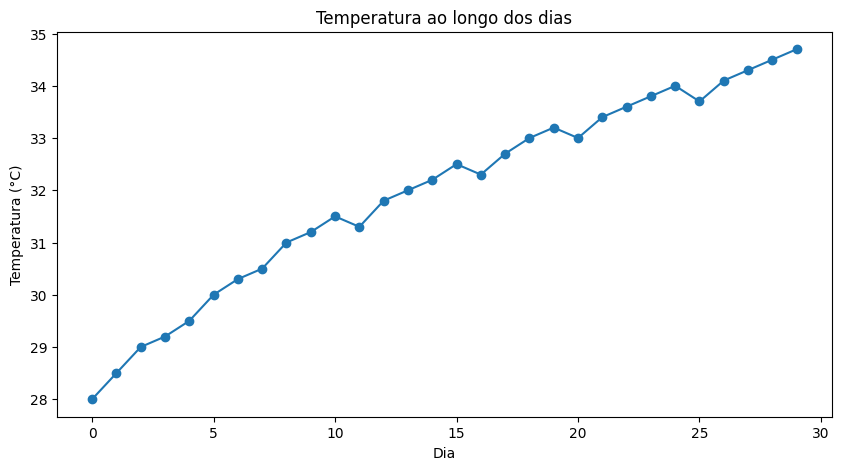

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(temperaturas, marker="o")
plt.title("Temperatura ao longo dos dias")
plt.xlabel("Dia")
plt.ylabel("Temperatura (°C)")
plt.show()


# Célula 4 - Separar treino, validação e teste

A divisão respeita a ordem temporal.


In [10]:
n = len(temperaturas)
fim_treino = int(n * 0.70)
fim_val = int(n * 0.85)

treino = temperaturas[:fim_treino]
validacao = temperaturas[fim_treino:fim_val]
teste = temperaturas[fim_val:]


# Célula 5 - Normalizar usando somente o treino


Os parâmetros da normalização são obtidos somente do treino.


In [11]:
temp_min = treino.min()
temp_max = treino.max()

def normalizar(v):
    return (v - temp_min) / (temp_max - temp_min)

treino_norm = normalizar(treino)
validacao_norm = normalizar(validacao)
teste_norm = normalizar(teste)


# Célula 6 - Criar janelas

Cada entrada contém três temperaturas anteriores e uma característica: temperatura.


In [12]:
janela = 3

def criar_janelas(dados, janela):
    X = []
    y = []

    for i in range(len(dados) - janela):
        X.append(dados[i:i + janela])
        y.append(dados[i + janela])

    X = np.array(X).reshape(-1, janela, 1)
    y = np.array(y)

    return X, y

X_train, y_train = criar_janelas(treino_norm, janela)
X_val, y_val = criar_janelas(validacao_norm, janela)
X_test, y_test = criar_janelas(teste_norm, janela)


# Célula 7 - Construir e compilar a RNN


Input(shape=(3, 1)) representa 3 passos de tempo e 1 característica.


In [13]:
model = Sequential([
    Input(shape=(3, 1)),
    SimpleRNN(32, activation="tanh"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


# Célula 8 - Treinar

Durante as épocas, a rede ajusta os pesos buscando reduzir o erro.


In [14]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    verbose=1
)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.7288 - mae: 0.8076 - val_loss: 1.7023 - val_mae: 1.3047
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.6280 - mae: 0.7494 - val_loss: 1.4797 - val_mae: 1.2164
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.5339 - mae: 0.6907 - val_loss: 1.2718 - val_mae: 1.1277
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.4470 - mae: 0.6316 - val_loss: 1.0793 - val_mae: 1.0389
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.3675 - mae: 0.5721 - val_loss: 0.9027 - val_mae: 0.9501
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.2956 - mae: 0.5124 - val_loss: 0.7425 - val_mae: 0.8617
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.2317 - mae: 0.4528 - val_loss: 0.5988 - val_mae: 0.7738
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.1758 - mae: 0.3933 - val_loss: 0.4720 - val_mae: 0.6870
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.1281 - mae: 

# Célula 9 - Prever e voltar para °C

As previsões são convertidas novamente para graus Celsius.


In [15]:
previsoes = model.predict(X_test)

previsoes_celsius = (
    previsoes.flatten() * (temp_max - temp_min)
) + temp_min

y_test_celsius = (
    y_test * (temp_max - temp_min)
) + temp_min


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


# Célula 10 - MAE e RMSE


MAE indica o erro médio em °C. RMSE dá maior peso a erros grandes.


In [16]:
mae = mean_absolute_error(
    y_test_celsius,
    previsoes_celsius
)

mse = mean_squared_error(
    y_test_celsius,
    previsoes_celsius
)

rmse = np.sqrt(mse)

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 1.3077909946441615
RMSE: 1.3087937203457594


# Célula 11 - Real × Previsto


Quanto mais próximas as curvas, mais próximas estão as previsões dos valores reais.

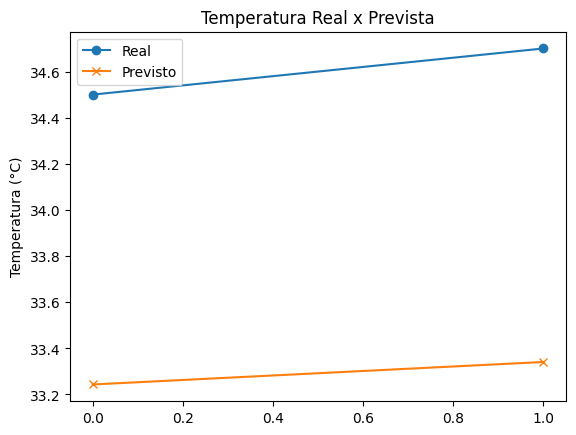

In [17]:
plt.plot(y_test_celsius, marker="o", label="Real")
plt.plot(previsoes_celsius, marker="x", label="Previsto")
plt.title("Temperatura Real x Prevista")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.show()
